### Equity / Balance tracker for MetaTrader5

This notebook cell loads and plots the balance history as stored here:scripts\outputs\balance_history.csv

In [54]:
def plot_equity_balance_history(balance=True, equity=True, start_date=None):
    # Load balance_history CSV and plot balance vs equity
    from pathlib import Path
    import pandas as pd
    import matplotlib.pyplot as plt

    CSV_PATH = Path('../scripts/outputs/balance_history.csv')

    if not CSV_PATH.exists():
        print(f"Balance file not found: {CSV_PATH}. Run the trading bot or ensure the path is correct.")
    else:
        df = pd.read_csv(CSV_PATH)
        # Parse timestamps
        if 'ts_utc' in df.columns:
            df['ts_utc'] = pd.to_datetime(df['ts_utc'], utc=True, errors='coerce')
            df = df.set_index('ts_utc').sort_index()
        # Ensure numeric columns
        for col in ('balance','equity','margin','margin_free','profit'):
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

        print(f"Loaded {len(df)} rows from {CSV_PATH}")
        # display(df.tail())
        if start_date:
            df = df[df.index >= pd.to_datetime(start_date, utc=True)]

        if 'balance' in df.columns or 'equity' in df.columns:
            plt.style.use('seaborn-v0_8')
            if balance and equity:
                col_to_plot = ['balance','equity']
            elif equity:
                col_to_plot = ['equity']
            elif balance:
                col_to_plot = ['balance']
            ax = df[col_to_plot].plot(figsize=(12,5), marker='o', markersize=3, linewidth=1)
            ax.set_title('Account Balance & Equity')
            ax.set_xlabel('UTC')
            ax.set_ylabel('Amount')
            ax.grid(True)
            plt.show()
        else:
            print('No balance/equity columns found to plot.')
    return df

Loaded 22305 rows from ..\scripts\outputs\balance_history.csv


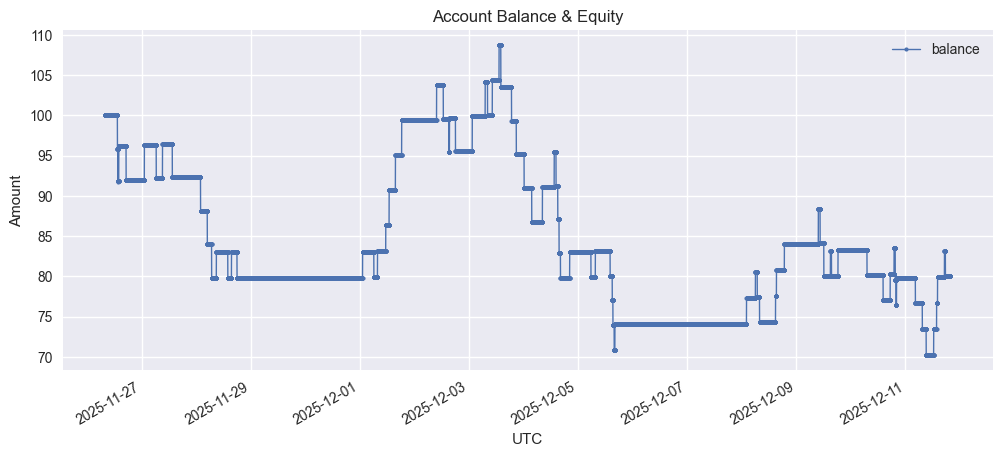

In [95]:
start_date = "2025-11-30 22:00:00+00:00"
start_date = None
df = plot_equity_balance_history(balance=True, equity=False, start_date=start_date)

# Need to print time sin
# ce new high and time since new low

In [90]:
df['balance'].max()
df['balance']
df

,balance,equity,margin,margin_free,leverage,profit
ts_utc,,,,,,
2025-11-26 07:50:23+00:00,100.00,100.00,0.0,100.00,100,0.0
2025-11-26 07:51:24+00:00,100.00,100.00,0.0,100.00,100,0.0
2025-11-26 07:52:24+00:00,100.00,100.00,0.0,100.00,100,0.0
2025-11-26 07:53:24+00:00,100.00,100.00,0.0,100.00,100,0.0
2025-11-26 07:54:24+00:00,100.00,100.00,0.0,100.00,100,0.0
...,...,...,...,...,...,...
2025-12-10 07:35:31+00:00,80.19,80.19,0.0,80.19,100,0.0
2025-12-10 07:36:31+00:00,80.19,80.19,0.0,80.19,100,0.0
2025-12-10 07:37:31+00:00,80.19,80.19,0.0,80.19,100,0.0


In [65]:
df #[df.index > "2025-12-01 19:05:59+00:00"]

df['equity'].max()
df

,balance,equity,margin,margin_free,leverage,profit
ts_utc,,,,,,
2025-11-30 22:00:22+00:00,79.84,77.26,34.81,42.45,100,-2.58
2025-11-30 22:01:22+00:00,79.84,77.26,34.81,42.45,100,-2.58
2025-11-30 22:02:22+00:00,79.84,77.26,34.81,42.45,100,-2.58
2025-11-30 22:03:22+00:00,79.84,77.26,34.81,42.45,100,-2.58
2025-11-30 22:04:22+00:00,79.84,77.26,34.81,42.45,100,-2.58
...,...,...,...,...,...,...
2025-12-01 19:13:59+00:00,99.40,101.28,46.45,54.83,100,1.88
2025-12-01 19:14:59+00:00,99.40,101.04,46.45,54.59,100,1.64
2025-12-01 19:15:59+00:00,99.40,101.12,46.45,54.67,100,1.72
